In [1]:
# Modules
import netcdf_read_write as nrw
import training_data_generation as tdg

# Librairies
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.interpolate import griddata


# 1. Déclaration des fonctions 

In [ ]:
def read_data(parameters,dataset_params):
    def imap_norm(intensity_map):
        avg_flux = np.mean(intensity_map) # average power per steradian (i.e. a flux)
        intensity_map_normalized = intensity_map / avg_flux - 1.0
        return intensity_map_normalized, avg_flux


    def imap2modes(intensity_map_normalized, LMAX):
        modes_complex = hp.sphtfunc.map2alm(intensity_map_normalized, lmax=LMAX)
        return modes_complex.real, modes_complex.imag


    def alms2rms(real_modes, imag_modes, lmax):
        # modes with m!=0 need to be x2 to account for negative terms
        # in healpix indexing the first lmax terms are all m=0
        pwr_spec_m0 = np.sum(np.abs(real_modes[:lmax]**2 + imag_modes[:lmax]**2))
        pwr_spec_rest = np.sum(np.abs(real_modes[lmax:]**2 + imag_modes[lmax:]**2)*2)
        rms = np.sqrt((pwr_spec_m0+pwr_spec_rest)/4.0/np.pi)
        return rms
    dataset = {}
    intensity_map = parameters["intensity"] * (dataset_params['illumination_evaluation_radii'] / 10000.0)**2 # convert to ?? W/sr ?
    dataset["nside"] = hp.get_nside(intensity_map)
    # print(f"Dataset nside: {dataset['nside']}")
    intensity_map_normalized, dataset["avg_flux"] = imap_norm(intensity_map)  
    dataset["real_modes"], dataset["imag_modes"]= imap2modes(intensity_map_normalized, dataset_params["LMAX"])
    dataset["rms"] = alms2rms(dataset["real_modes"], dataset["imag_modes"], dataset_params["LMAX"])
    dataset["power_deposited"] = dataset["avg_flux"] * 4.0 * np.pi
    return dataset

def plot_intensity_map(dataset, dataset_params,display_steradians=False):
    def modes2imap(real_modes, imag_modes, imap_nside):
        np_complex = np.vectorize(complex)
        modes_complex = np_complex(real_modes, imag_modes)
        intensity_map_normalized = hp.alm2map(modes_complex, imap_nside)
        return intensity_map_normalized
    
    avg_flux = dataset["avg_flux"]
    real_modes = dataset["real_modes"]
    imag_modes = dataset["imag_modes"]
    rms = dataset["rms"]

    intensity_map_normalized = modes2imap(real_modes, imag_modes, dataset_params["imap_nside"])
    intensity_map_sr = (intensity_map_normalized+1)*avg_flux

   
    drive_map = intensity_map_normalized * 100.
    if display_steradians:
        drive_units = r"Intensity {:.1e} $ \rm W/sr   (\pm \%) $".format(avg_flux)
    else:
        drive_units = r"Intensity {:.1e} $ \rm W/cm^2 (\pm \%) $".format(avg_flux / (float(dataset_params['illumination_evaluation_radii'][0]) / 10000.0)**2)

    mapmin = np.round(np.min(drive_map), +1-int(np.floor(np.log10(abs(np.min(drive_map))))))
    mapmax = np.round(np.max(drive_map), +1-int(np.floor(np.log10(abs(np.max(drive_map))))))
    hp.mollview(drive_map, unit=drive_units,flip="geo", min=mapmin, max=mapmax)
    hp.graticule()

def plot_power_spectrum(dataset, dataset_params):
    def alms2power_spectrum(alms, LMAX):
        the_modes = np.zeros(LMAX)
        the_modes_full = np.zeros((LMAX,LMAX+1))
        for l in range(LMAX):
            for m in range(l+1):
                the_modes_full[l,m] = np.real(alms[hp.sphtfunc.Alm.getidx(LMAX, l, m)]*np.conjugate(alms[hp.sphtfunc.Alm.getidx(LMAX, l, m)]))
                if (m>0):
                    the_modes[l] = the_modes[l] + 2.*the_modes_full[l,m]
                else:          
                    the_modes[l] = the_modes[l] + the_modes_full[l,m]

        the_modes = the_modes / (4.*np.pi)
        return the_modes

    real_modes = dataset["real_modes"]
    imag_modes = dataset["imag_modes"]
    complex_modes = real_modes + 1j * imag_modes
    power_spectrum = alms2power_spectrum(complex_modes, dataset_params["LMAX"])

    LMAX = dataset_params["LMAX"]
    fig = plt.figure()
    ax = plt.axes()
    plt.plot(np.arange(LMAX), np.sqrt(power_spectrum) * 100.0)
    ax.set_xticks(range(0, LMAX+1, 1))
    plt.xlim([0, LMAX])
    plt.title("Intensity Modes")
    plt.xlabel("l mode")
    plt.ylabel(r"amplitude ($\%$)")
    
def plot_sigma_RMS(dataset, dataset_params):
    rms = dataset["rms"]
    avg_flux = dataset["avg_flux"]
    sigma_percent = rms / avg_flux * 100.0
    print(f"RMS: {rms:.2e} % of the average flux {avg_flux:.2e} W/sr (1e+12 = 1 TW)")
    return rms

def plot_intensity_sphere(p_in_z1z2_beam_all_0):
    theta = np.array(p_in_z1z2_beam_all_0['theta'])
    phi = np.array(p_in_z1z2_beam_all_0['phi'])
    I = np.array(p_in_z1z2_beam_all_0['intensity'])

    # Grille fine en theta et phi
    n_theta, n_phi = 180, 360
    theta_grid = np.linspace(0, np.pi, n_theta)
    phi_grid = np.linspace(0, 2*np.pi, n_phi)
    theta_mesh, phi_mesh = np.meshgrid(theta_grid, phi_grid)

    # Interpoler l'intensité sur la grille
    points = np.column_stack((theta, phi))
    grid_points = np.column_stack((theta_mesh.ravel(), phi_mesh.ravel()))
    I_grid = griddata(points, I, grid_points, method='linear').reshape(theta_mesh.shape)

    # Coordonnées cartésiennes de la surface
    x = np.sin(theta_mesh) * np.cos(phi_mesh)
    y = np.sin(theta_mesh) * np.sin(phi_mesh)
    z = np.cos(theta_mesh)

    # Figure Plotly
    fig = go.Figure(data=[go.Surface(
        x=x, y=y, z=z,
        surfacecolor=I_grid,
        colorscale='plasma',
        cmin=np.nanmin(I_grid), cmax=np.nanmax(I_grid)
    )])
    fig.update_traces(showscale=True, colorbar_title='Intensité')
    fig.update_layout(
        title='Sphère d’intensité',
        scene=dict(aspectmode='data',
                xaxis_title='X', yaxis_title='Y', zaxis_title='Z'),
        width=700, height=700
    )
    fig.show()

def carte_mode_unique(alm, l, m, nside):
    """
    Reconstruit la carte de la composante (l, m) seule.
    Pour m>0, la fonction alm2map utilise automatiquement la symétrie
    a_{l,-m} = (-1)^m a_{l,m}^* pour produire une carte réelle.
    """
    lmax = hp.Alm.getlmax(alm.size)
    alm_mode = np.zeros_like(alm)
    idx = hp.Alm.getidx(lmax, l, m)
    alm_mode[idx] = alm[idx]
    return hp.alm2map(alm_mode, nside, verbose=False)

def carte_mode_l(alm, l, nside):
    """
    Reconstruit la carte de la somme sur tous les m pour un l donné
    (c'est-à-dire la projection sur le sous-espace de degré l).
    """
    lmax = hp.Alm.getlmax(alm.size)
    alm_l = np.zeros_like(alm)
    for m in range(l + 1):
        idx = hp.Alm.getidx(lmax, l, m)
        alm_l[idx] = alm[idx]
    return hp.alm2map(alm_l, nside, verbose=False)

def carte_vers_3d_plotly(carte, nside, titre="Carte 3D"):
    """
    Convertit une carte HEALPix en surface 3D Plotly.
    """
    # Récupérer les coordonnées des pixels
    theta, phi = hp.pix2ang(nside, np.arange(len(carte)))
    
    # Conversion en coordonnées cartésiennes
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    
    # Normaliser les couleurs
    colors = (carte - carte.min()) / (carte.max() - carte.min())
    
    fig = go.Figure(data=[go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(
            size=5,
            color=carte,
            colorscale='RdBu',
            colorbar=dict(title="Amplitude"),
            cmin=-np.max(np.abs(carte)),
            cmax=np.max(np.abs(carte)),
            showscale=True
        ),
        text=[f"θ={t:.2f}, φ={p:.2f}, val={v:.4f}" 
              for t, p, v in zip(theta, phi, carte)],
        hoverinfo='text'
    )])
    
    fig.update_layout(
        title=titre,
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
            aspectmode='data'
        )
    )
    
    return fig


# 2. Chargement des données

In [3]:
main_dir = "../Data/Data_run4"
sys_params = tdg.define_system_params(main_dir)
second_dir = "../Data/Data_run4/config_0/time_0"

dataset_params = nrw.read_general_netcdf(main_dir + "/" + sys_params["dataset_params_filename"])
num_perturbations = dataset_params["num_perturbations"]

p_in_z1z2_beam_all = []
for i in range(num_perturbations):
    p_in_z1z2_beam_all.append(nrw.read_general_netcdf(second_dir + "/pert_" + str(i) + "/p_in_z1z2_beam_all.nc"))

dataset = []
for i in range(num_perturbations):
    dataset.append(read_data(p_in_z1z2_beam_all[i],dataset_params))


In [4]:
facility_spec = nrw.read_general_netcdf(sys_params["data_dir"] + "/" + sys_params["facility_spec_filename"])

deck_gen_params = nrw.read_general_netcdf(sys_params["data_dir"] + "/" + sys_params["deck_gen_params_filename"])

# 3. Visualisation de l'intensité 

## 3.1 Carte de Mollweide

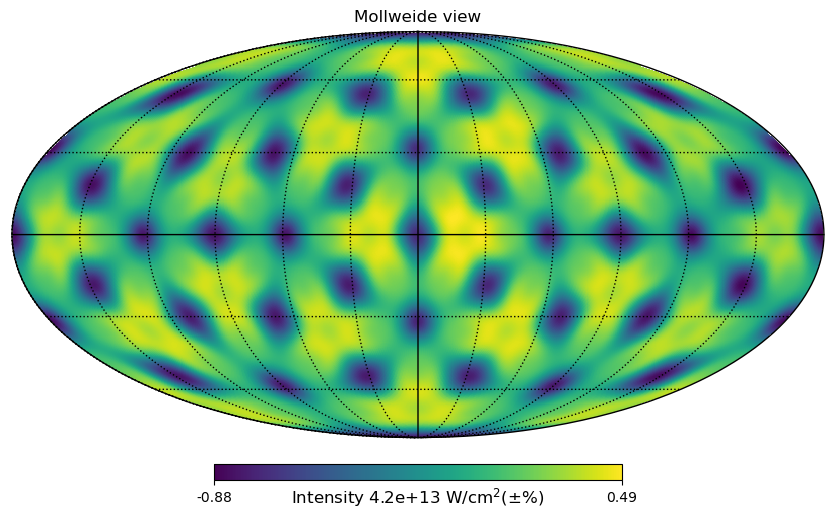

In [5]:
for i in range(0, num_perturbations):
    plot_intensity_map(dataset[i], dataset_params, display_steradians=False)

In [6]:
for i in range(0,num_perturbations):
    plot_intensity_sphere(p_in_z1z2_beam_all[i])

# 4. Analyse des modes 

## 4.1 Amplitude des modes 

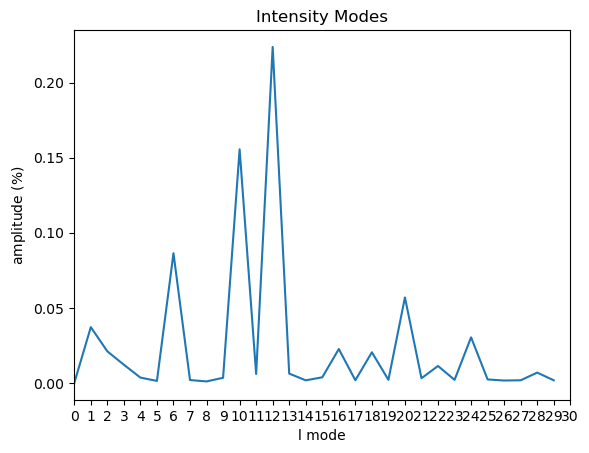

In [7]:
for i in range(0, num_perturbations):
    plot_power_spectrum(dataset[i], dataset_params)

## 4.2 Visualisation des modes d'intérêts

/tmp/ipykernel_5275/104652531.py:154: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  return hp.alm2map(alm_l, nside, verbose=False)


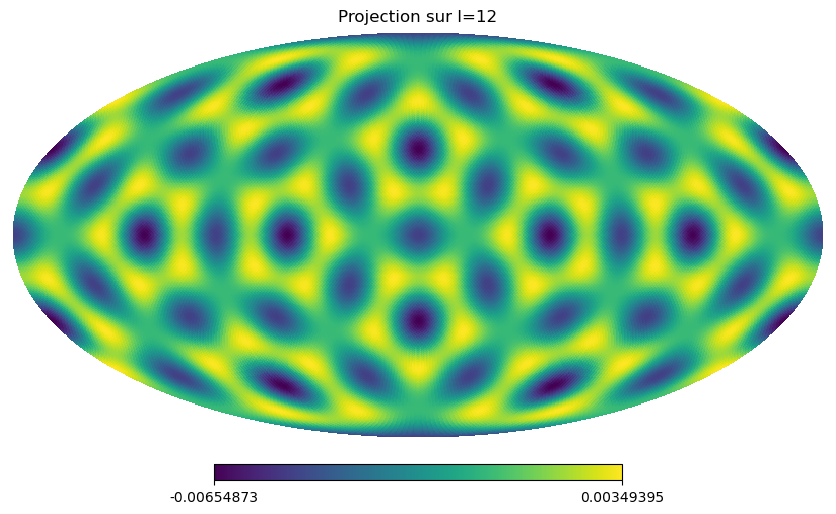

In [8]:
# # Visualisation d'un mode particulier
# n_side = dataset[0]["nside"] # assuming all datasets have the same nside
# alm = dataset[0]["real_modes"] + 1j * dataset[0]["imag_modes"]
# carte = carte_mode_unique(alm, l=1, m=1, nside=n_side)
# hp.mollview(carte, title="Mode (l=3, m=2)")

# Visualisation de tout le degré l
l=12
n_side = dataset[0]["nside"] # assuming all datasets have the same nside
alm = dataset[0]["real_modes"] + 1j * dataset[0]["imag_modes"]
carte_l = carte_mode_l(alm, l=l, nside=n_side)
hp.mollview(carte_l, title=f"Projection sur l={l}")

In [9]:
n_side = dataset[0]["nside"] 
fig = carte_vers_3d_plotly(carte_l, n_side, f"Projection l={l}")
fig.show()

# 5. Analyse du sigma RMS

RMS: 2.99e-03 % of the average flux 2.24e+12 W/sr (1e+12 = 1 TW)


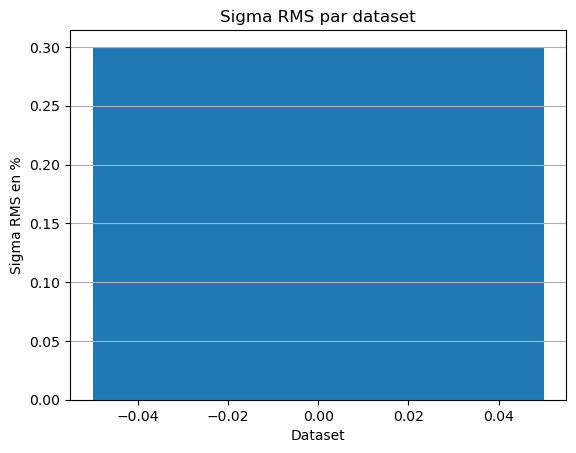

In [10]:
xarray = np.arange(len(dataset))
values = []
for i in range(len(dataset)):
    sigma = plot_sigma_RMS(dataset[i], dataset_params)
    values.append(100*float(sigma.item()))  # sigma.item() c'est un ndarray de taille 1

plt.bar(xarray, values, width=0.1)
plt.xlabel("Dataset")
plt.ylabel("Sigma RMS en %")
plt.title("Sigma RMS par dataset")
plt.grid(axis='y')
plt.show()